In [53]:
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt, hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import matplotlib.pyplot as plt
from scipy.signal import decimate

In [54]:
noise_band = [0,0.5]
delta_band = [0.5,5]
theta_band = [4,8]
sigma_band = [11,17]
beta_band = [22,30]
gamma_band = [8,12]
total_band = [0,30]
alpha_band = [8,12]

In [55]:
def normalized_cross_correlation(epoch1, epoch2):
    # zero-mean
    x = epoch1 - np.mean(epoch1)
    y = epoch2 - np.mean(epoch2)
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    if denom == 0:
        return 0.0
    return np.sum(x * y) / denom

def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    out = []
    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        e1 = EOG1[i:i + samples]
        e2 = EOG2[i:i + samples]
        # Use normalized cross-correlation (value in [-1,1])
        out.append(normalized_cross_correlation(e1, e2))
    return np.array(out)

def auto_correlation_slope(EOG, epoch_length, fs, min_slope_idx=1):
    samples = int(epoch_length * fs)
    slopes = []
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac_full = np.correlate(epoch, epoch, mode='full')
        center = len(ac_full) // 2
        ac = ac_full[center:]  # non-negative lags
        # normalize ac so ac[0] == 1 (helps numeric stability)
        if ac[0] == 0:
            slopes.append(np.nan)
            continue
        ac = ac / ac[0]
        peaks, _ = find_peaks(ac)
        # find first peak with index >= min_slope_idx
        valid_peaks = [p for p in peaks if p >= min_slope_idx]
        if len(valid_peaks) < 1:
            slopes.append(np.nan)
            continue
        first_peak_idx = valid_peaks[0]
        # slope between lag 0 and first_peak_idx
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)
    return np.array(slopes)

def auto_correlation(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    auto_corr = np.array([])
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        squared = np.sum(epoch*epoch)
        auto_corr = np.append(auto_corr, squared)
    return(auto_corr)

In [56]:
def feature_b(EOG1, EOG2, epoch_length, fs):
    b_features = np.array([])
    EOG1 = decimate(EOG1, int(fs/50))
    EOG2 = decimate(EOG2, int(fs/50))
    fs = 50
    b, a = butter(4, [0.1 / (0.5 * fs), 0.45 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_corr_val = auto_correlation(EOG1, epoch_length, fs)
    for count, ac in enumerate(auto_corr_val):
        feature = (np.mean(np.abs(ac))) * cross_cor_val[count]
        b_features = np.append(b_features, feature)
    return b_features

def feature_c(EOG1, EOG2, epoch_length, fs):
    c_features = np.array([])
    EOG1 = decimate(EOG1, int(fs/50))
    EOG2 = decimate(EOG2, int(fs/50))
    fs = 50
    b, a = butter(4, [0.3 / (0.5 * fs), 0.45 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_corr_val = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, ac in enumerate(auto_corr_val):
        feature = (1-ac) * cross_cor_val[count]
        c_features = np.append(c_features, feature)
    return c_features

def new_index_N(eog_features, delta, alpha, EMG):
    alt_index_n = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*delta[i])/(alpha[i]*EMG[i])
        alt_index_n = np.append(alt_index_n, [value])
        
    return alt_index_n

def rem_feature(EOG1, EOG2, epoch_length, fs,
                slope_tol=1e-6, max_inv=1e6, clip_abs=None):
    # filter (check nyquist and signal length outside)
    nyq = 0.5 * fs
    low = 0.3 / nyq
    high = 35.0 / nyq
    if not (0 < low < 1 and 0 < high < 1 and low < high):
        raise ValueError("Filter cutoff frequencies invalid for fs={}".format(fs))
    b, a = butter(4, [low, high], btype='band')
    # be careful: filtfilt requires signal length > padlen (approx 3*max(len(a),len(b)))
    if len(EOG1) < 20 or len(EOG2) < 20:
        raise ValueError("Signals too short for reliable filtering.")
    EOG1_f = filtfilt(b, a, EOG1)
    EOG2_f = filtfilt(b, a, EOG2)

    cross_cor_val = cross_correlation(EOG1_f, EOG2_f, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1_f, epoch_length, fs)

    features = []
    for cc, slope in zip(cross_cor_val, auto_slope):
        if np.isnan(slope) or abs(slope) < slope_tol:
            inv = 0.0  # or np.nan depending on whether you want to keep epoch
        else:
            inv = 1.0 / slope
            # guard against absurdly large values
            if not np.isfinite(inv):
                inv = 0.0
            if max_inv is not None:
                if inv > max_inv:
                    inv = max_inv
                elif inv < -max_inv:
                    inv = -max_inv
        # keep sign of cross-corr but use normalized cc in [-1,1]
        feat = np.sign(cc) * inv
        features.append(feat)

    feats = np.array(features)
    if clip_abs is not None:
        feats = np.clip(feats, -clip_abs, clip_abs)
    return feats

In [57]:
def nindex_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

In [58]:
def alt_index_w(theta, gamma, EMG, delta, sigma, eog, alpha, eogb, beta):
    index_w = np.array([])
    for i in range(len(EMG)):
        value = ((1-eog[i])*(1-eog[i]))/(0.25*eogb[i]*sigma[i])
        index_w = np.append(index_w, [value])
    return index_w

In [59]:
def index_R(delta, sigma, EMG, eog_features):
    alt_index_r = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*eog_features[i])/(EMG[i]*EMG[i]*delta[i]*sigma[i])
        alt_index_r = np.append(alt_index_r, [value])
        
    return alt_index_r


In [60]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [61]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [62]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

In [63]:
subject = "2"
night = "1"
file_type = "converted_uni_and_bi"
hpc_channel = 'TR10'
pfc_channel = "TL01"
os.makedirs(os.path.join("C:/EEG_Data_stage","W_test", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","W_test", file_type, subject, f"night{night}")

In [64]:
fs = 250  
window_length = 10 * fs
epoch_length = int(window_length / fs)

In [65]:
files, scores_files = fragment_join(subject, night, file_type)
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband ed

In [66]:
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

In [67]:
EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [68]:
sleep_scoring = np.ravel(states)
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
state_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [69]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs

In [70]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)[0]
raw_pfc = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)[0]

In [71]:
# raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
# fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
# noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [72]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

In [73]:
feature_b = feature_b(EOG1, EOG2, epoch_length, fs)
feature_c = feature_c(EOG1, EOG2, epoch_length, fs)
feature_a = rem_feature(EOG1, EOG2, epoch_length, fs)
feature_a = wei_normalizing(feature_a)
feature_b = wei_normalizing(feature_b)
feature_c = wei_normalizing(feature_c)
feature_a = np.convolve(np.convolve(np.convolve(feature_a, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
feature_c = np.convolve(np.convolve(np.convolve(feature_c, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
feature_b = np.convolve(np.convolve(np.convolve(feature_b, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [74]:
print(len(EMG_norm))
print(len(delta_norm))

4318
4318


In [75]:
index_n = new_index_N(feature_c, delta_norm, alpha_norm, EMG_norm)
index_n = wei_normalizing(index_n)
index_n =np.convolve(np.convolve(np.convolve(index_n, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [76]:
index_r = index_R(delta_norm, sigma_norm, EMG_norm, feature_a)
index_r = wei_normalizing(index_r)
index_r = np.convolve(np.convolve(np.convolve(index_r, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [77]:
index_w = nindex_W(theta_norm, gamma_norm, EMG_norm)

alt_index_w = alt_index_w(theta_norm, gamma_norm, EMG_norm, delta_norm, sigma_norm, index_n, alpha_norm, index_r, beta_norm)

index_w = wei_normalizing(index_w)
index_w = np.convolve(np.convolve(np.convolve(index_w, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
print(len(index_w))
print(len(alt_index_w))
alt_index_w = wei_normalizing(alt_index_w)
alt_index_w = np.convolve(np.convolve(np.convolve(alt_index_w, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

4318
4318


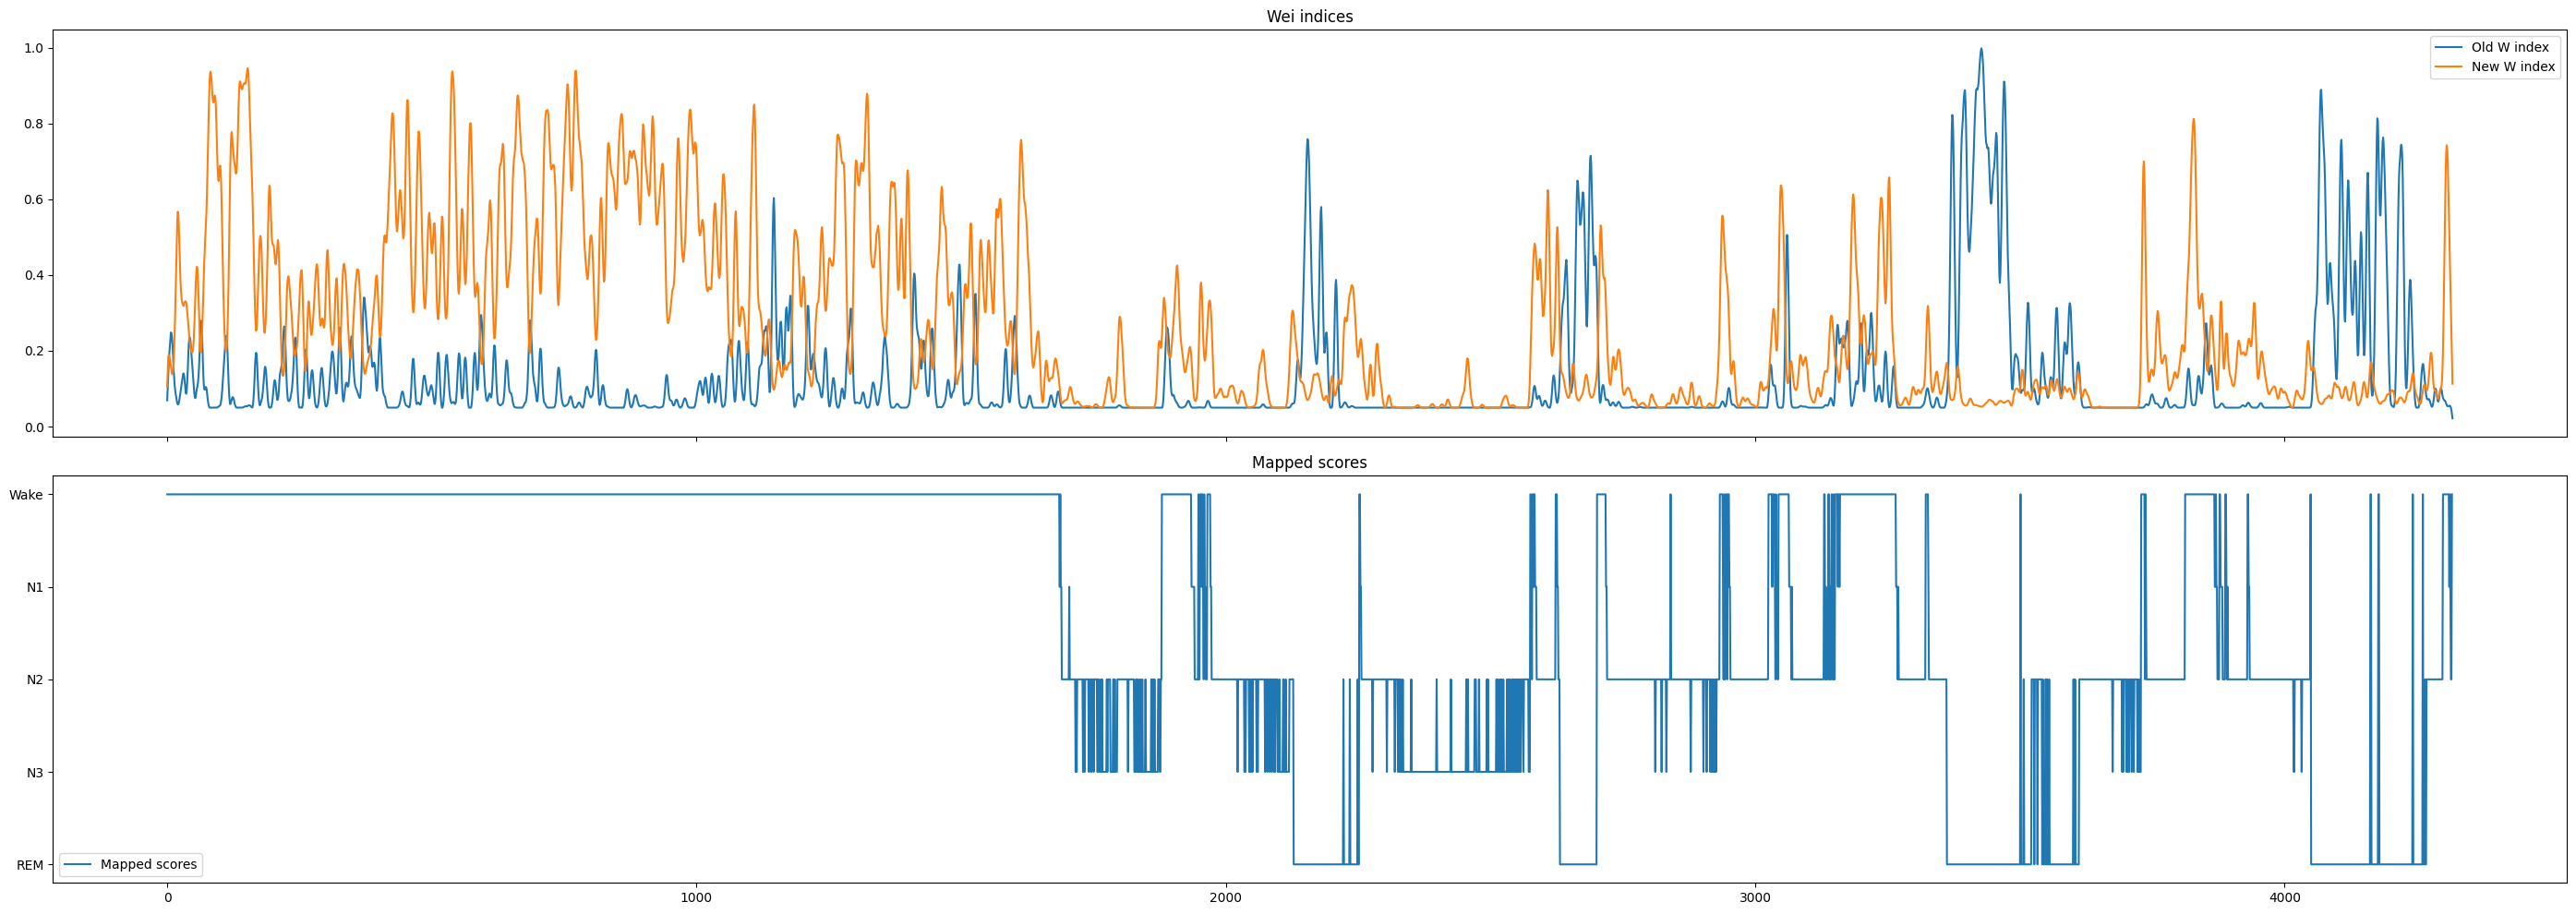

In [78]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))
# Plot data on each subplot
epochs = np.arange(len(feature_b))
ax1.plot(epochs, index_r, label='Old W index')
ax1.plot(epochs, alt_index_w, label='New W index')
ax2.plot(hypno_epochs, mapped_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('Wei indices')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/Wei_indices_original.svg", format='svg')
# Show the plots
plt.show()